## Should I use PCA or an Autoencoder

- **We’ll do this by:**
 - Comparing **reconstruction error**
 - Comparing **latent geometry**
 - Understanding **when AEs win**
 - Understanding **when AEs fundamentally fail**

| Scenario                         | PCA       | Linear AE     | Nonlinear AE                         |
| -------------------------------- | --------- | ------------- | ------------------------------------ |
| Linear structure                 | ✅ Optimal | ✅ Same as PCA | ❌ Overkill                           |
| Curved manifold                  | ❌ Fails   | ❌ Fails       | ✅ Wins                               |
| Symmetric / multi-valued mapping | ❌ Fails   | ❌ Fails       | ❌ (unless latent ↑ or probabilistic) |
| Small data                       | ✅ Stable  | ⚠️ Risky      | ❌ Overfits                           |
| Interpretability                 | ✅ High    | ⚠️ Medium     | ❌ Low                                |


- #### Dataset preparation
    - **Dataset A — Linear (easy)**: y=2x+ϵ
    - **Dataset B — Curved (nonlinear)**: y=x2+ϵ
    - **Dataset C — Unstructured noise**: x∼N(0,I)

- **Metric: Reconstruction Error (the only fair metric)** 
    - Lets use MSE:  MSE=1/N ∑∥x−x^∥2


#### Prepare 3 datsets and plot it 

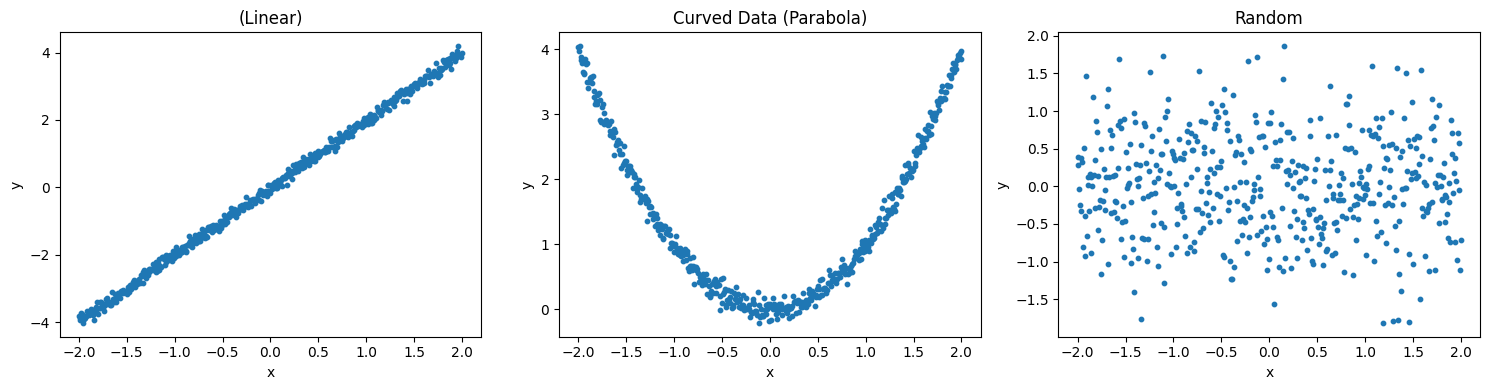

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

t = np.linspace(-2, 2, 500)
x_1 = t
y_1 = 2 * t + np.random.normal(0, 0.1, size=t.shape)

dataset_A = np.stack([x_1, y_1], axis=1)

x_2 = t
y_2 = t**2 + np.random.normal(0, 0.1, size=t.shape)

dataset_B = np.stack([x_2, y_2], axis=1)

x_3 = t
y_3 = np.random.normal(0, 0.5, size=t.shape) + np.random.normal(0, 0.5, size=t.shape)

dataset_C = np.stack([x_3, y_3], axis=1)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    
axs[0].scatter(dataset_A[:, 0], dataset_A[:, 1], s=10)
axs[0].set_title("(Linear)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].scatter(dataset_B[:, 0], dataset_B[:, 1], s=10)
axs[1].set_title("Curved Data (Parabola)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

axs[2].scatter(dataset_C[:, 0], dataset_C[:, 1], s=10)
axs[2].set_title("Random")
axs[2].set_xlabel("x")
axs[2].set_ylabel("y")

plt.tight_layout()
plt.show()



In [24]:
def plot_original_vs_reconstructed(A_original,A_reconstructed,B_original,B_reconstructed,C_original,C_reconstructed, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].scatter(A_original[:, 0], A_original[:, 1], s=10, label="Original")
    axs[0].scatter(A_reconstructed[:, 0], A_reconstructed[:, 1], s=10, label=title+"_Reconstructed")
    axs[0].set_title("(Linear)")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].legend() 

    axs[1].scatter(B_original[:, 0], B_original[:, 1], s=10, label="Original")
    axs[1].scatter(B_reconstructed[:, 0], B_reconstructed[:, 1], s=10, label=title+"_Reconstructed")
    axs[1].set_title("(Non-linear)")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")
    axs[1].legend() 

    axs[2].scatter(C_original[:, 0], C_original[:, 1], s=10, label="Original")
    axs[2].scatter(C_reconstructed[:, 0], C_reconstructed[:, 1], s=10, label=title+"_Reconstructed")
    axs[2].set_title("(random noise)")
    axs[2].set_xlabel("x")
    axs[2].set_ylabel("y")
    axs[2].legend() 

### Reduce these 2d data to 1d data by PCA, then resconstruct back

- Use PCA to reduce the dimenssion then use **inverse_transform** to transform it back


In [5]:
from sklearn.decomposition import PCA

def pca_reconstruct(X, k):
    pca = PCA(n_components=k)
    Z = pca.fit_transform(X)
    X_hat = pca.inverse_transform(Z)
    return X_hat

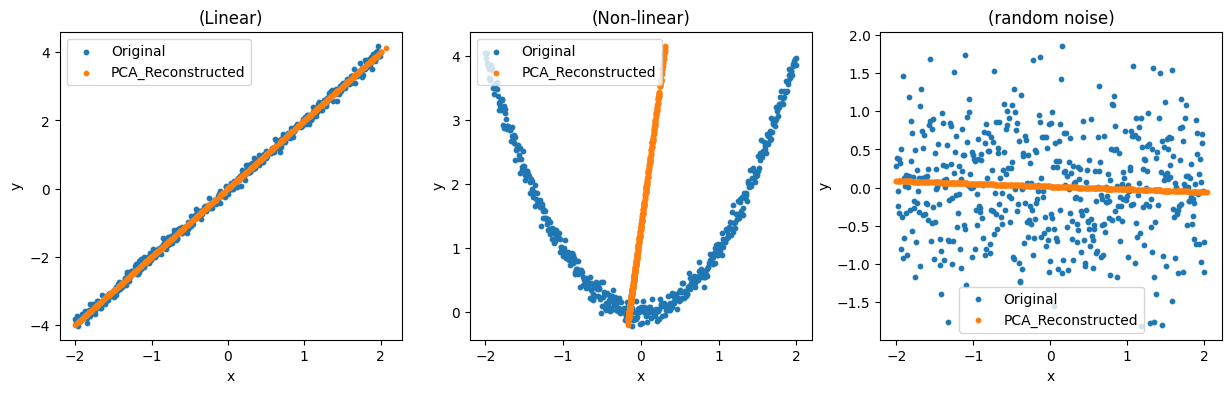

In [25]:
# Reduce and reconstruct each dataset using PCA with k=1

dataset_A_pca_reconstructed = pca_reconstruct(dataset_A, k=1)
dataset_B_pca_reconstructed = pca_reconstruct(dataset_B, k=1)   
dataset_C_pca_reconstructed = pca_reconstruct(dataset_C, k=1)


plot_original_vs_reconstructed(dataset_A, dataset_A_pca_reconstructed, dataset_B, dataset_B_pca_reconstructed, dataset_C, dataset_C_pca_reconstructed, title="PCA")

### Reduce and reconstruct 2d data to 1d by linear Autoencoder
- Define linear Autocoder model
- Linear auto encoder model, there is no Activation. 

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

class LinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.Linear(16, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)    


In [30]:
def train_linear_autoencoder(model, dataset, num_epochs=2000):
    model = LinearAE()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()  
    model.train()
    X = torch.tensor(dataset, dtype=torch.float32)
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        X_hat = model(X)
        loss = loss_fn(X_hat, X)
        loss.backward()
        optimizer.step()
    return model   

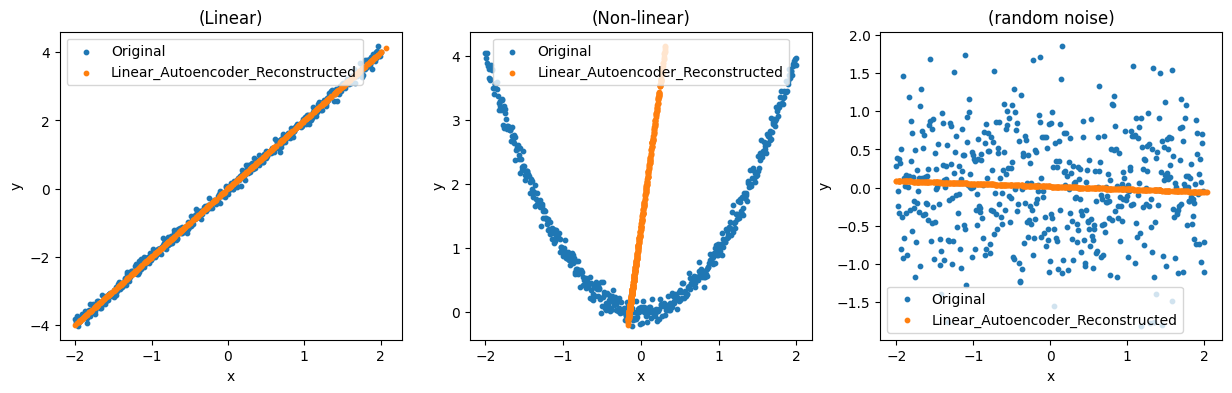

In [31]:
dataset_A_linear_model = train_linear_autoencoder(LinearAE(), dataset_A)
dataset_B_linear_model = train_linear_autoencoder(LinearAE(), dataset_B)
dataset_C_linear_model = train_linear_autoencoder(LinearAE(), dataset_C)

dataset_A_linear_ae_reconstructed = dataset_A_linear_model(torch.tensor(dataset_A, dtype=torch.float32)).detach().numpy()
dataset_B_linear_ae_reconstructed = dataset_B_linear_model(torch.tensor(dataset_B, dtype=torch.float32)).detach().numpy()
dataset_C_linear_ae_reconstructed = dataset_C_linear_model(torch.tensor(dataset_C, dtype=torch.float32)).detach().numpy()

plot_original_vs_reconstructed(dataset_A, dataset_A_linear_ae_reconstructed, dataset_B, dataset_B_linear_ae_reconstructed, dataset_C, dataset_C_linear_ae_reconstructed, title="Linear_Autoencoder") 

### Reduce and reconstruct 2d data to 1d by Non-linear Autoencoder

- Define Non-lenear Autocoder model

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

class NonLinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)    


- **Define the training method which will return the model after trained with the given dataset**

In [33]:
def train_non_linear_autoencoder(model, dataset, num_epochs=2000):
    model = NonLinearAE()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()  
    model.train()
    X = torch.tensor(dataset, dtype=torch.float32)
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        X_hat = model(X)
        loss = loss_fn(X_hat, X)
        loss.backward()
        optimizer.step()
    return model    

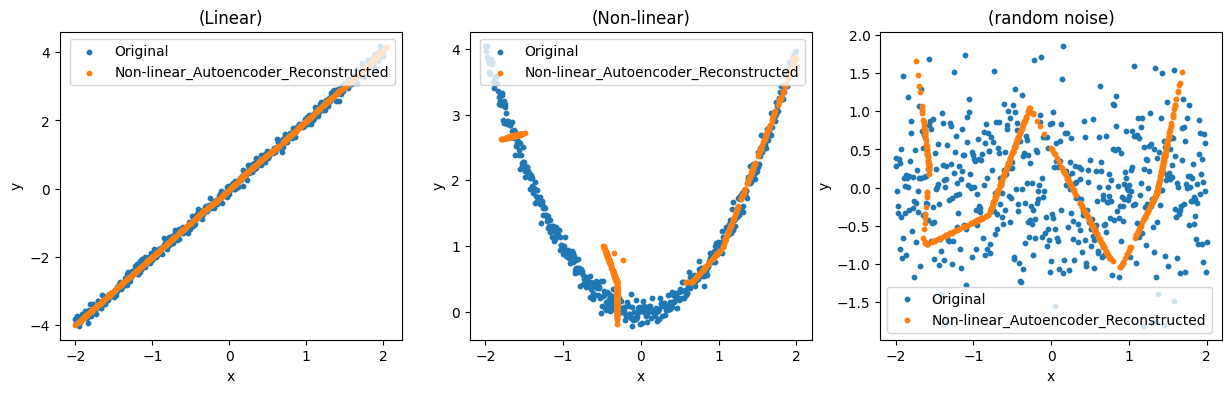

In [36]:
dataset_A_non_linear_ae_model = train_non_linear_autoencoder(NonLinearAE(), dataset_A)
dataset_B_non_linear_ae_model = train_non_linear_autoencoder(NonLinearAE(), dataset_B)
dataset_C_non_linear_ae_model = train_non_linear_autoencoder(NonLinearAE(), dataset_C)

dataset_A_non_linear_ae_reconstructed = dataset_A_non_linear_ae_model(torch.tensor(dataset_A, dtype=torch.float32)).detach().numpy()
dataset_B_non_linear_ae_reconstructed = dataset_B_non_linear_ae_model(torch.tensor(dataset_B, dtype=torch.float32)).detach().numpy()
dataset_C_non_linear_ae_reconstructed = dataset_C_non_linear_ae_model(torch.tensor(dataset_C, dtype=torch.float32)).detach().numpy()

plot_original_vs_reconstructed(dataset_A, dataset_A_non_linear_ae_reconstructed, dataset_B, dataset_B_non_linear_ae_reconstructed, dataset_C, dataset_C_non_linear_ae_reconstructed, title="Non-linear_Autoencoder") 

### Quantitative comparison of PCA vs Linear Autoencoder vs non-linear Autoencoder

#### Dataset A (Linear data)

| Method       | Reconstruction Error |
| ------------ | -------------------- |
| PCA (k=1)    | ✅ Lowest             |
| Linear AE    | ✅ Same               |
| Nonlinear AE | ⚠️ Slightly worse    |


#### Dataset B (Curved data)

| Method       | Reconstruction Error |
| ------------ | -------------------- |
| PCA (k=1)    | ❌ High               |
| Linear AE    | ❌ High               |
| Nonlinear AE | ✅ Much lower         |


#### Dataset C (random noise data)

| Method | Reconstruction Error |
| ------ | -------------------- |
| PCA    | ❌ High               |
| AE     | ❌ High               |


### Latent geometry comparison (very important)

#### PCA latent space
 - Linear projection
 - Preserves variance
 - Interpretable axes

#### Autoencoder latent space
 - Nonlinear coordinates
 - Can warp space
 - Optimized for reconstruction, not variance

**💡 Key insight**

 - PCA finds the best linear coordinate system.
 - AE learns any coordinate system that reconstructs well.

### Why autoencoders sometimes look “worse” than PCA
**Reasons:**
 1. Optimization noise
 2. Overfitting
 3. Poor architecture choice
 4. Too-small dataset
 5. Bad latent dimension 

**PCA:**
 - Closed-form
 - Deterministic
 - No overfitting

**Autoencoders:**

 - Flexible
 - Powerful
 - Dangerous without discipline

### When to use which one
**✅ Use PCA when:**

 - Data is small
 - Structure is roughly linear
 - Interpretability matters
 - You want stability

**✅ Use Autoencoder when:**

 - Data lies on nonlinear manifold
 - You have enough data
 - Reconstruction quality matters
 - You want learned features

**❌ Don’t use AE when:**

 - Data is mostly noise
 - Latent dimension too small for topology
 - You need exact reconstruction
 - You need guarantees 

##### PCA finds the best straight explanation.
##### Autoencoders find any explanation that works.


### Difference between linear AutoEncoder and non-linear Autoencoder.

#### What a linear autoencoder really is
- **Definition**

A linear autoencoder is an autoencoder where:
 - Encoder = linear map
 - Decoder = linear map
 - No nonlinear activations anywhere

- **Mathematically:**
    - **𝑧 = 𝑊𝑒 𝑥**  -> z is the latent space, encoders output
    - **𝑥^ = 𝑊𝑑 𝑧** -> 𝑥^ is the final prediction, decoder output.
    - This means: **𝑥^ = 𝑊𝑑 𝑊𝑒 𝑥**
	​
- Which is just:
  - One big linear transformation

- **Consequence (very important)**
  - A linear autoencoder can only:
    - Rotate
    - Scale
    - Project
 - **It can never bend space**.

- SO it can only learn from Linear subspaces 
- **Linear AE ≡ PCA (under MSE + bottleneck)**

#### What non-linearity actually gives you
- When you add any non-linear activation (ReLU, tanh, sigmoid, GELU):
- 𝑧 = 𝑓d( 𝑊d 𝑓e(𝑊e 𝑥)) -> 𝑓d and 𝑓e can be any activation function. (ReLU,tanh,sigmoid,GELU,Swish,ELU)
- Even one nonlinearity is enough.

| Property          | Linear AE | Non-linear AE |
| ----------------- | --------- | ------------- |
| Activation        | None      | Any           |
| Function class    | Linear    | Non-linear    |
| Manifold learning | ❌         | ✅             |
| Equivalent to PCA | ✅         | ❌             |


- It can:
  - **Bend space**
  - **Stretch some regions**
  - **Compress others**
- That’s why it handled the parabola better (but still hit topology limits).

#### Use Non-linear AE when:

  - Data lies on curved manifolds
  - Structure is complex
  - You have enough data
  - Reconstruction matters